In [11]:
# 202431191_M. Sidiq Maulana
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
import matplotlib.colors as mcolors

In [12]:
# 202431191_M. Sidiq Maulana
url_worldometer = 'https://www.worldometers.info/world-population/population-by-country/'
header = {"User-Agent": "Mozilla/5.0"}
req_worldometer = requests.get(url_worldometer, headers=header)
tabel_worldometer = pd.read_html(req_worldometer.text)
df_populasi = tabel_worldometer[0]

print("Data dari Website Worldometer")
display(df_populasi.head())

Data dari Website Worldometer


/tmp/ipykernel_1250/3461221541.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tabel_worldometer = pd.read_html(req_worldometer.text)


,#,Country (or dependency),Population 2026,Yearly Change,Net Change,Density (P/KmÂ²),Land Area (KmÂ²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1476625576,0.87%,12760051,497,2973190,"â440,456",1.93,29.2,37.6%,17.8%
1,2,China,1412914089,â0.22%,"â3,182,005",150,9388211,"â232,107",1.03,40.6,68.7%,17%
2,3,United States,349035494,0.51%,1759687,38,9147420,1177848,1.63,38.7,83.1%,4.2%
3,4,Indonesia,287886782,0.76%,2165546,159,1811570,"â39,472",2.08,30.7,60.3%,3.5%
4,5,Pakistan,259299791,1.6%,4080237,336,770880,"â1,144,738",3.44,20.8,34.7%,3.1%


In [13]:
# 202431191_M. Sidiq Maulana
url_scrape = 'https://www.scrapethissite.com/pages/forms/'
header = {"User-Agent": "Mozilla/5.0"}
req_scrape = requests.get(url_scrape, headers=header)
tabel_scrape = pd.read_html(req_scrape.text)
df_hoki = tabel_scrape[0]

print("Data dari Website Scrape")
display(df_hoki.head())

Data dari Website Scrape


/tmp/ipykernel_1250/112970415.py:5: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tabel_scrape = pd.read_html(req_scrape.text)


,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


In [14]:
# 202431191_M. Sidiq Maulana
df_csv = pd.read_csv('/content/Sleep_health_and_lifestyle_dataset.csv')
display(df_csv.head())

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


EDA (Exploratory Data Analysis)

In [15]:
# 202431191_M. Sidiq Maulana
df_kotor = pd.concat([df_csv, df_csv.iloc[[0,1]]], ignore_index=True)

print(f"Jumlah baris awal: {len(df_csv)}, setelah kotor: {len(df_kotor)}")

Jumlah baris awal: 374, setelah kotor: 376


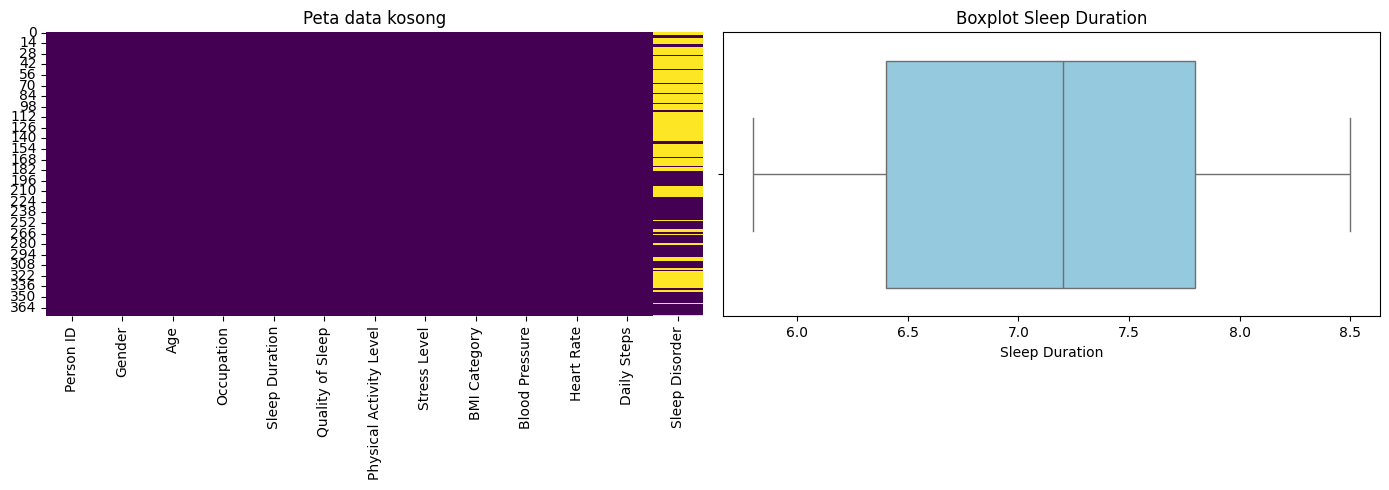

In [16]:
# 202431191_M. Sidiq Maulana
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(df_kotor.isnull(), cbar=False, cmap='viridis', ax=ax[0])
ax[0].set_title('Peta data kosong')

sns.boxplot(x=df_kotor['Sleep Duration'], ax=ax[1], color='skyblue')
ax[1].set_title('Boxplot Sleep Duration')

plt.tight_layout()
plt.show()

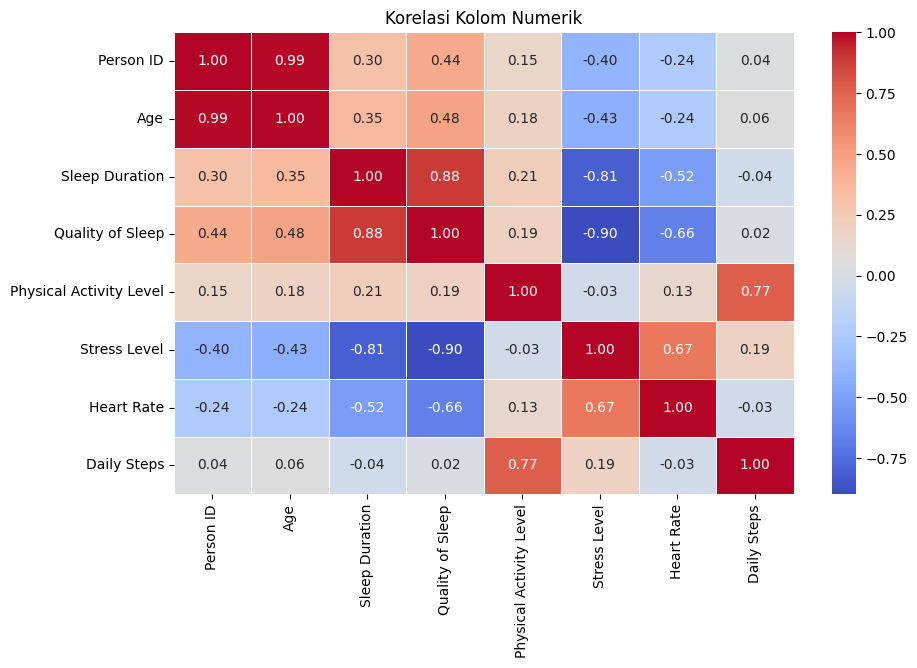

In [17]:
# 202431191_M. Sidiq Maulana
kolom_numerik = df_kotor.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 6))
sns.heatmap(kolom_numerik.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Korelasi Kolom Numerik')
plt.show()

In [18]:
# 202431191_M. Sidiq Maulana
diabetes = datasets.load_diabetes()
x_reg = diabetes.data[:, np.newaxis,2]
y_reg = diabetes.target

iris = datasets.load_iris()
x_clf = iris.data[:,:2]
y_clf = iris.target

print("Dataset berhasil dimuat")

Dataset berhasil dimuat


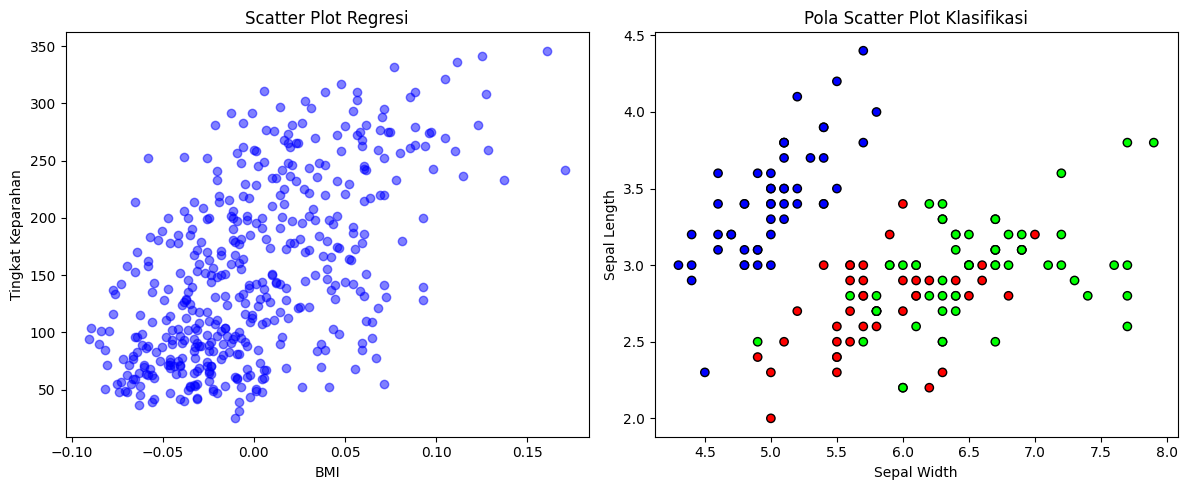

In [19]:
# 202431191_M. Sidiq Maulana
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(x_reg, y_reg, color='blue', alpha=0.5)
ax[0].set_xlabel('BMI')
ax[0].set_ylabel('Tingkat Keparahan')
ax[0].set_title('Scatter Plot Regresi')

scatter = ax[1].scatter(x_clf[:, 0], x_clf[:, 1], c=y_clf, cmap='brg', edgecolor = 'k')
ax[1].set_xlabel('Sepal Width')
ax[1].set_ylabel('Sepal Length')
ax[1].set_title('Pola Scatter Plot Klasifikasi')

plt.tight_layout()
plt.show()

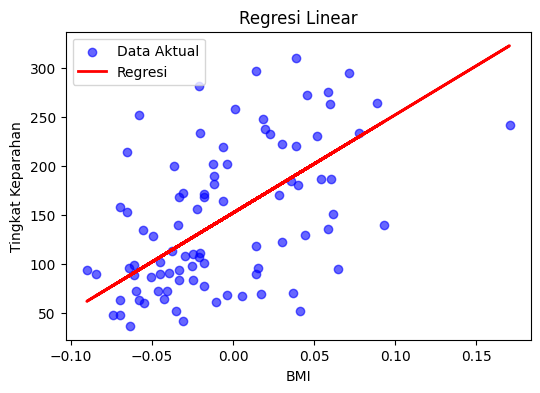

Tingkat Keparahan untuk BMI 22.49134948096886 adalah 22611.36314450562


In [20]:
# 202431191_M. Sidiq Maulana
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_reg, y_reg, test_size=0.2, random_state=42)

model_reg = LinearRegression()
model_reg.fit(x_train_reg, y_train_reg)

y_pred_reg = model_reg.predict(x_test_reg)

plt.figure(figsize=(6, 4))
plt.scatter(x_test_reg, y_test_reg, color='blue', alpha=0.6, label='Data Aktual')
plt.plot(x_test_reg, y_pred_reg, color='red', linewidth=2, label='Regresi')
plt.xlabel('BMI')
plt.ylabel('Tingkat Keparahan')
plt.title('Regresi Linear')
plt.legend()
plt.show()

berat_badan = 65
tinggi_badan = 170
bmi = berat_badan / ((tinggi_badan/100)**2)
bmi_baru = np.array([[bmi]])
prediksi_diabetes = model_reg.predict(bmi_baru)
print(f"Tingkat Keparahan untuk BMI {bmi} adalah {prediksi_diabetes[0]}")